# ⚔️ Komparasi Model: XGBoost vs Random Forest
**Dataset:** Teen_Mental_Health_Dataset.csv  
**Target:** `depression_label` (0 = Tidak Depresi, 1 = Depresi)  
**Alur:** Load Data → Preprocessing → SMOTE → Training → Evaluasi → Komparasi → Kesimpulan

---
## 📦 Cell 1 — Install Library

In [1]:
%pip install xgboost imbalanced-learn scikit-learn pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 📚 Cell 2 — Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## 📂 Cell 3 — Load & Preprocessing Data

In [3]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
df_model = df.copy()

le = LabelEncoder()
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop('depression_label', axis=1)
y = df_model['depression_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'  Total data           : {len(X)}')
print(f'  Data train (SMOTE)   : {len(X_train_smote)}')
print(f'  Data test            : {len(X_test)}')
print('✅ Preprocessing selesai!')

  Total data           : 1200
  Data train (SMOTE)   : 1870
  Data test            : 240
✅ Preprocessing selesai!


---
## 🚀 Cell 4 — Training Kedua Model

In [4]:
# --- XGBoost ---
print('Training XGBoost...')
xgb_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 5,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0
)
xgb_model.fit(X_train_smote, y_train_smote, verbose=False)
print('✅ XGBoost selesai!')

# --- Random Forest ---
print('Training Random Forest...')
rf_model = RandomForestClassifier(
    n_estimators      = 200,
    max_depth         = 10,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = 'sqrt',
    random_state      = 42,
    n_jobs            = -1
)
rf_model.fit(X_train_smote, y_train_smote)
print('✅ Random Forest selesai!')

Training XGBoost...
✅ XGBoost selesai!
Training Random Forest...
✅ Random Forest selesai!


---
## 📊 Cell 5 — Evaluasi Test Set

In [5]:
models = {
    'XGBoost'       : xgb_model,
    'Random Forest' : rf_model
}

results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'y_pred'    : y_pred,
        'y_prob'    : y_prob,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'auc'       : roc_auc_score(y_test, y_prob),
        'f1'        : f1_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred),
        'recall'    : recall_score(y_test, y_pred),
    }

print('=' * 65)
print('              PERBANDINGAN HASIL — TEST SET')
print('=' * 65)
print(f"{'Metrik':<20} {'XGBoost':>18} {'Random Forest':>18} {'Winner':>8}")
print('-' * 65)
metric_keys   = ['accuracy', 'auc', 'f1', 'precision', 'recall']
for m in metric_keys:
    xgb_val = results['XGBoost'][m]
    rf_val  = results['Random Forest'][m]
    winner  = '🟠 XGB' if xgb_val > rf_val else '🟢 RF'
    print(f"  {m.capitalize():<18} {xgb_val:>18.4f} {rf_val:>18.4f} {winner:>8}")
print('=' * 65)

              PERBANDINGAN HASIL — TEST SET
Metrik                          XGBoost      Random Forest   Winner
-----------------------------------------------------------------
  Accuracy                       1.0000             0.9958    🟠 XGB
  Auc                            1.0000             1.0000     🟢 RF
  F1                             1.0000             0.9091    🟠 XGB
  Precision                      1.0000             1.0000     🟢 RF
  Recall                         1.0000             0.8333    🟠 XGB


---
## 🔄 Cell 6 — Cross Validation (5-Fold)

In [6]:
print('Running Cross Validation... (harap tunggu)')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])
    results[name]['cv_acc'] = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    results[name]['cv_auc'] = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    results[name]['cv_f1']  = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
    print(f'✅ CV {name} selesai!')

print()
print('=' * 70)
print('           PERBANDINGAN HASIL — CROSS VALIDATION (5-Fold)')
print('=' * 70)
print(f"{'Metrik':<18} {'XGBoost (mean±std)':>22} {'Random Forest (mean±std)':>26} {'Winner':>8}")
print('-' * 70)
cv_metrics = [('cv_acc', 'CV Accuracy'), ('cv_auc', 'CV AUC'), ('cv_f1', 'CV F1')]
for key, label in cv_metrics:
    xgb_mean = results['XGBoost'][key].mean()
    rf_mean  = results['Random Forest'][key].mean()
    xgb_std  = results['XGBoost'][key].std()
    rf_std   = results['Random Forest'][key].std()
    winner   = '🟠 XGB' if xgb_mean > rf_mean else '🟢 RF'
    print(f"  {label:<16} {xgb_mean:.4f} ± {xgb_std:.4f}     {rf_mean:.4f} ± {rf_std:.4f}   {winner}")
print('=' * 70)

Running Cross Validation... (harap tunggu)
✅ CV XGBoost selesai!
✅ CV Random Forest selesai!

           PERBANDINGAN HASIL — CROSS VALIDATION (5-Fold)
Metrik                 XGBoost (mean±std)   Random Forest (mean±std)   Winner
----------------------------------------------------------------------
  CV Accuracy      0.9983 ± 0.0020     0.9958 ± 0.0046   🟠 XGB
  CV AUC           0.9975 ± 0.0040     0.9980 ± 0.0040   🟢 RF
  CV F1            0.9664 ± 0.0413     0.8998 ± 0.1225   🟠 XGB


---
## 📈 Cell 7 — Visualisasi Perbandingan

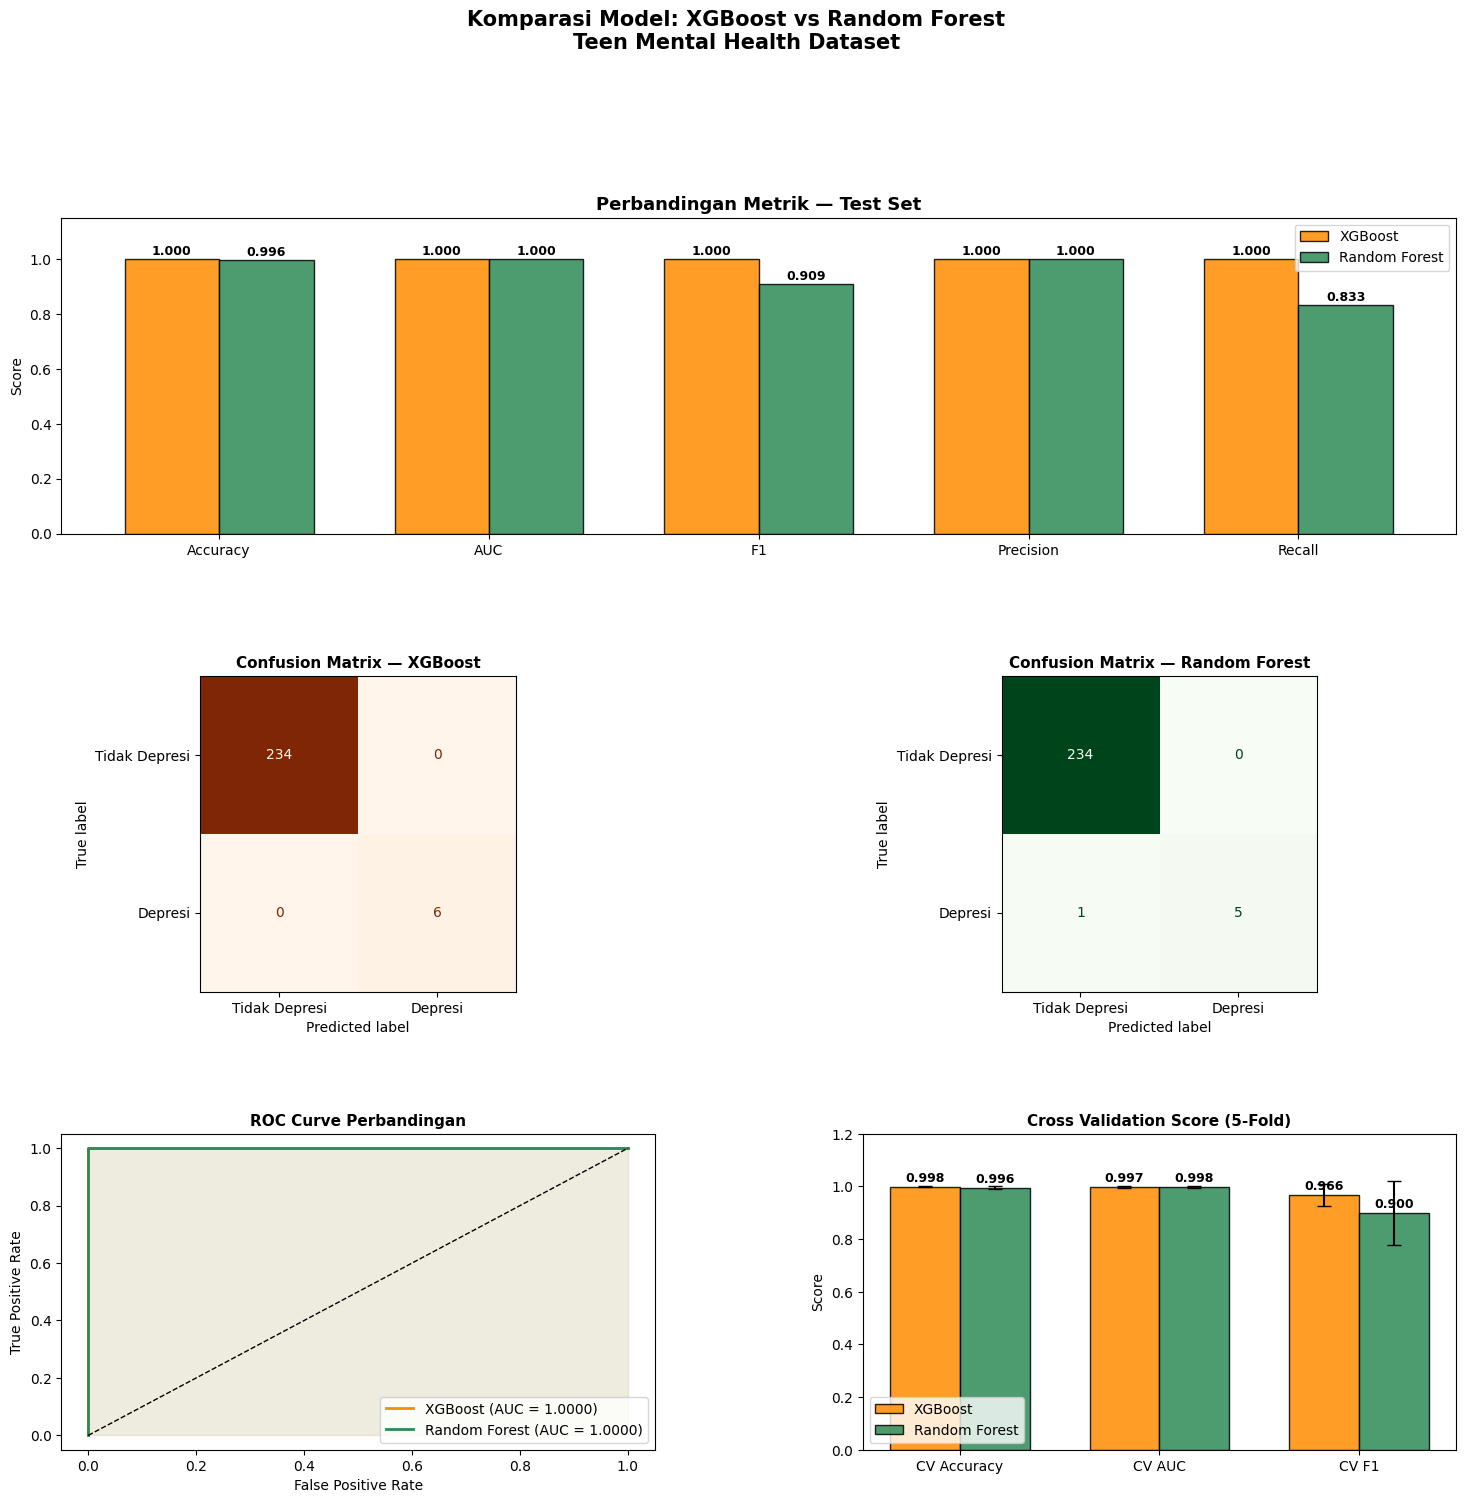

✅ Grafik disimpan ke models/comparison_result.png


In [7]:
colors = {'XGBoost': 'darkorange', 'Random Forest': 'seagreen'}

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: Bar Chart Metrik Test Set ---
ax1 = fig.add_subplot(gs[0, :])
metric_names = ['Accuracy', 'AUC', 'F1', 'Precision', 'Recall']
xgb_scores   = [results['XGBoost'][m] for m in metric_keys]
rf_scores    = [results['Random Forest'][m] for m in metric_keys]

x     = np.arange(len(metric_names))
width = 0.35
bars1 = ax1.bar(x - width/2, xgb_scores, width, label='XGBoost',
                color='darkorange', edgecolor='black', alpha=0.85)
bars2 = ax1.bar(x + width/2, rf_scores,  width, label='Random Forest',
                color='seagreen',   edgecolor='black', alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Perbandingan Metrik — Test Set', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names)
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Score')
ax1.legend()

# --- Plot 2 & 3: Confusion Matrix ---
for idx, (name, model) in enumerate(models.items()):
    ax = fig.add_subplot(gs[1, idx])
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Tidak Depresi', 'Depresi']
    ).plot(ax=ax, cmap='Oranges' if name == 'XGBoost' else 'Greens', colorbar=False)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=11, fontweight='bold')

# --- Plot 4: ROC Curve Gabungan ---
ax4 = fig.add_subplot(gs[2, 0])
for name, color in colors.items():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc_val      = results[name]['auc']
    ax4.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.4f})')
    ax4.fill_between(fpr, tpr, alpha=0.08, color=color)
ax4.plot([0, 1], [0, 1], 'k--', lw=1)
ax4.set_title('ROC Curve Perbandingan', fontsize=11, fontweight='bold')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.legend(loc='lower right')

# --- Plot 5: CV Score Comparison ---
ax5 = fig.add_subplot(gs[2, 1])
cv_labels = ['CV Accuracy', 'CV AUC', 'CV F1']
cv_keys   = ['cv_acc', 'cv_auc', 'cv_f1']
xgb_cv    = [results['XGBoost'][k].mean() for k in cv_keys]
rf_cv     = [results['Random Forest'][k].mean() for k in cv_keys]
xgb_std   = [results['XGBoost'][k].std() for k in cv_keys]
rf_std    = [results['Random Forest'][k].std() for k in cv_keys]

x2    = np.arange(len(cv_labels))
bars3 = ax5.bar(x2 - width/2, xgb_cv, width, yerr=xgb_std,
                label='XGBoost', color='darkorange', edgecolor='black',
                alpha=0.85, capsize=5)
bars4 = ax5.bar(x2 + width/2, rf_cv,  width, yerr=rf_std,
                label='Random Forest', color='seagreen', edgecolor='black',
                alpha=0.85, capsize=5)
for bar in bars3:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars4:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

ax5.set_title('Cross Validation Score (5-Fold)', fontsize=11, fontweight='bold')
ax5.set_xticks(x2)
ax5.set_xticklabels(cv_labels)
ax5.set_ylim(0, 1.2)
ax5.set_ylabel('Score')
ax5.legend()

plt.suptitle('Komparasi Model: XGBoost vs Random Forest\nTeen Mental Health Dataset',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('models/comparison_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan ke models/comparison_result.png')

---
## 🌟 Cell 8 — Feature Importance Perbandingan

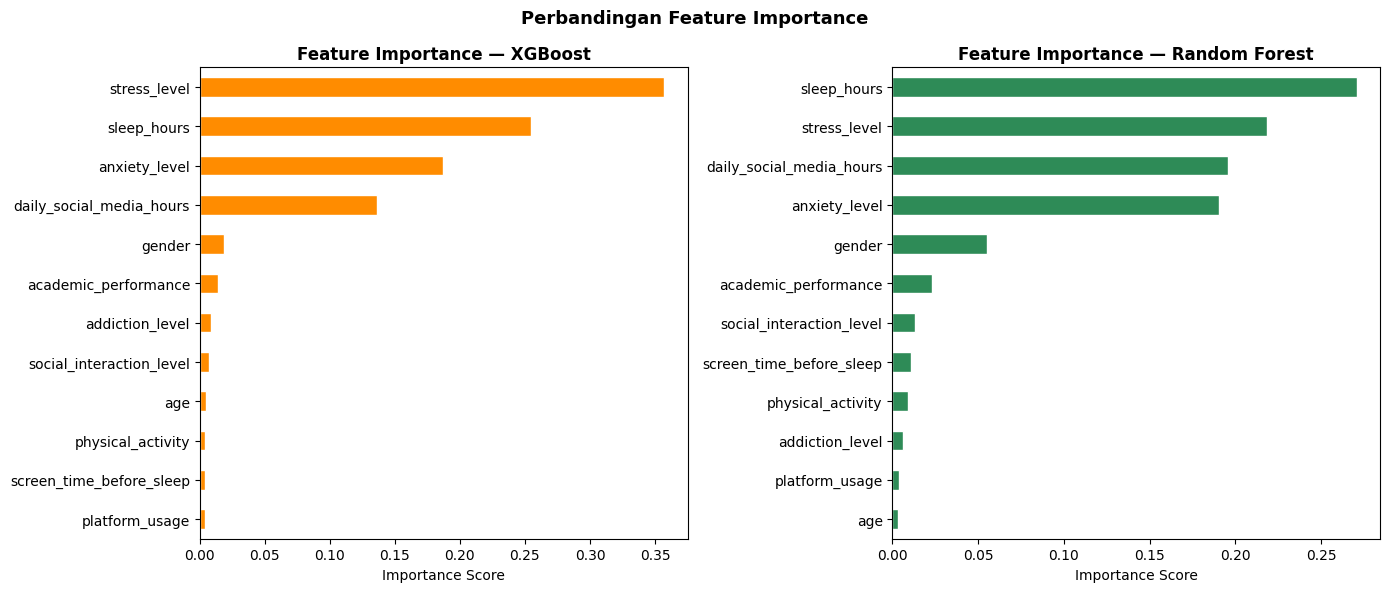

--- Top 3 Fitur XGBoost ---
stress_level     0.357161
sleep_hours      0.254708
anxiety_level    0.187256

--- Top 3 Fitur Random Forest ---
sleep_hours                 0.270685
stress_level                0.218540
daily_social_media_hours    0.195513


In [8]:
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X.columns)
rf_imp  = pd.Series(rf_model.feature_importances_,  index=X.columns)

imp_df = pd.DataFrame({
    'XGBoost'       : xgb_imp,
    'Random Forest' : rf_imp
}).sort_values('XGBoost', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

imp_df['XGBoost'].plot(
    kind='barh', ax=axes[0], color='darkorange', edgecolor='white'
)
axes[0].set_title('Feature Importance — XGBoost', fontweight='bold')
axes[0].set_xlabel('Importance Score')

imp_df['Random Forest'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen', edgecolor='white'
)
axes[1].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Perbandingan Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('--- Top 3 Fitur XGBoost ---')
print(xgb_imp.sort_values(ascending=False).head(3).to_string())
print()
print('--- Top 3 Fitur Random Forest ---')
print(rf_imp.sort_values(ascending=False).head(3).to_string())

---
## 🏆 Cell 9 — Kesimpulan Otomatis

In [9]:
score_board = {'XGBoost': 0, 'Random Forest': 0}

# Voting dari metrik test set
for m in metric_keys:
    if results['XGBoost'][m] > results['Random Forest'][m]:
        score_board['XGBoost'] += 1
    else:
        score_board['Random Forest'] += 1

# Voting dari cross validation
for key, _ in cv_metrics:
    if results['XGBoost'][key].mean() > results['Random Forest'][key].mean():
        score_board['XGBoost'] += 1
    else:
        score_board['Random Forest'] += 1

best_model = max(score_board, key=score_board.get)

print('=' * 52)
print('                   KESIMPULAN')
print('=' * 52)
print(f"  Total metrik yang dibandingkan : {sum(score_board.values())}")
print(f"  🟠 XGBoost menang      : {score_board['XGBoost']} metrik")
print(f"  🟢 Random Forest menang: {score_board['Random Forest']} metrik")
print()
print(f"  🏆 MODEL TERBAIK : {best_model}")
print()
print(f"  Detail hasil {best_model}:")
print(f"    Accuracy  : {results[best_model]['accuracy']:.4f}")
print(f"    AUC       : {results[best_model]['auc']:.4f}")
print(f"    F1 Score  : {results[best_model]['f1']:.4f}")
print(f"    Precision : {results[best_model]['precision']:.4f}")
print(f"    Recall    : {results[best_model]['recall']:.4f}")
print(f"    CV Acc    : {results[best_model]['cv_acc'].mean():.4f} ± {results[best_model]['cv_acc'].std():.4f}")
print(f"    CV AUC    : {results[best_model]['cv_auc'].mean():.4f} ± {results[best_model]['cv_auc'].std():.4f}")
print(f"    CV F1     : {results[best_model]['cv_f1'].mean():.4f} ± {results[best_model]['cv_f1'].std():.4f}")
print('=' * 52)

                   KESIMPULAN
  Total metrik yang dibandingkan : 8
  🟠 XGBoost menang      : 5 metrik
  🟢 Random Forest menang: 3 metrik

  🏆 MODEL TERBAIK : XGBoost

  Detail hasil XGBoost:
    Accuracy  : 1.0000
    AUC       : 1.0000
    F1 Score  : 1.0000
    Precision : 1.0000
    Recall    : 1.0000
    CV Acc    : 0.9983 ± 0.0020
    CV AUC    : 0.9975 ± 0.0040
    CV F1     : 0.9664 ± 0.0413
